In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np,gc # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sn
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/new-york-city/nyc-parking-tickets/Parking_Violations_Issued_-_Fiscal_Year_2017.csv
/kaggle/input/datasets/organizations/new-york-city/nyc-parking-tickets/Parking_Violations_Issued_-_Fiscal_Year_2016.csv
/kaggle/input/datasets/organizations/new-york-city/nyc-parking-tickets/Parking_Violations_Issued_-_Fiscal_Year_2014__August_2013___June_2014_.csv
/kaggle/input/datasets/organizations/new-york-city/nyc-parking-tickets/Parking_Violations_Issued_-_Fiscal_Year_2015.csv


In [2]:
#!pip install wordcloud

In [3]:
#from wordcloud import WordCloud, STOPWORDS

# Import Dataset

In [4]:
file_path = '/kaggle/input/datasets/organizations/new-york-city/nyc-parking-tickets/Parking_Violations_Issued_-_Fiscal_Year_2017.csv'
df_2017 = pd.read_csv(file_path, low_memory=False)
df_2017.head()

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,...,Vehicle Color,Unregistered Vehicle?,Vehicle Year,Meter Number,Feet From Curb,Violation Post Code,Violation Description,No Standing or Stopping Violation,Hydrant Violation,Double Parking Violation
0,5092469481,GZH7067,NY,PAS,07/10/2016,7,SUBN,TOYOT,V,0,...,GY,NaN,2001,NaN,0,NaN,FAILURE TO STOP AT RED LIGHT,NaN,NaN,NaN
1,5092451658,GZH7067,NY,PAS,07/08/2016,7,SUBN,TOYOT,V,0,...,GY,NaN,2001,NaN,0,NaN,FAILURE TO STOP AT RED LIGHT,NaN,NaN,NaN
2,4006265037,FZX9232,NY,PAS,08/23/2016,5,SUBN,FORD,V,0,...,BK,NaN,2004,NaN,0,NaN,BUS LANE VIOLATION,NaN,NaN,NaN
3,8478629828,66623ME,NY,COM,06/14/2017,47,REFG,MITSU,T,10610,...,WH,NaN,2007,NaN,0,04,47-Double PKG-Midtown,NaN,NaN,NaN
4,7868300310,37033JV,NY,COM,11/21/2016,69,DELV,INTER,T,10510,...,WHITE,NaN,2007,NaN,0,31 6,69-Failure to Disp Muni Recpt,NaN,NaN,NaN


The device only can run a dataset (2015,2016, or 2017)

In [5]:
#df_2015 = pd.read_csv('/kaggle/input/datasets/organizations/new-york-city/nyc-parking-tickets/Parking_Violations_Issued_-_Fiscal_Year_2015.csv',low_memory=False)
#df_2016 = pd.read_csv('/kaggle/input/datasets/organizations/new-york-city/nyc-parking-tickets/Parking_Violations_Issued_-_Fiscal_Year_2016.csv',low_memory=False)

In [6]:
df_zero_null_columns_2017=df_2017.dropna(axis=1, how='all')
df_zero_null_columns_2017.head()

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,...,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Unregistered Vehicle?,Vehicle Year,Meter Number,Feet From Curb,Violation Post Code,Violation Description
0,5092469481,GZH7067,NY,PAS,07/10/2016,7,SUBN,TOYOT,V,0,...,NaN,NaN,NaN,GY,NaN,2001,NaN,0,NaN,FAILURE TO STOP AT RED LIGHT
1,5092451658,GZH7067,NY,PAS,07/08/2016,7,SUBN,TOYOT,V,0,...,NaN,NaN,NaN,GY,NaN,2001,NaN,0,NaN,FAILURE TO STOP AT RED LIGHT
2,4006265037,FZX9232,NY,PAS,08/23/2016,5,SUBN,FORD,V,0,...,NaN,NaN,NaN,BK,NaN,2004,NaN,0,NaN,BUS LANE VIOLATION
3,8478629828,66623ME,NY,COM,06/14/2017,47,REFG,MITSU,T,10610,...,Y,0700A,0700P,WH,NaN,2007,NaN,0,04,47-Double PKG-Midtown
4,7868300310,37033JV,NY,COM,11/21/2016,69,DELV,INTER,T,10510,...,Y,0700A,0700P,WHITE,NaN,2007,NaN,0,31 6,69-Failure to Disp Muni Recpt


In [7]:
df_2017.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10803028 entries, 0 to 10803027
Data columns (total 43 columns):
 #   Column                             Dtype  
---  ------                             -----  
 0   Summons Number                     int64  
 1   Plate ID                           object 
 2   Registration State                 object 
 3   Plate Type                         object 
 4   Issue Date                         object 
 5   Violation Code                     int64  
 6   Vehicle Body Type                  object 
 7   Vehicle Make                       object 
 8   Issuing Agency                     object 
 9   Street Code1                       int64  
 10  Street Code2                       int64  
 11  Street Code3                       int64  
 12  Vehicle Expiration Date            int64  
 13  Violation Location                 float64
 14  Violation Precinct                 int64  
 15  Issuer Precinct                    int64  
 16  Issuer Code     

In [8]:
df_2017.shape[0]

10803028

In [9]:
df_2017.shape[1]

43

# EDA

## NaN Identification
We will explore this 2017 dataset to calculate NaN values inside each columns.

In [10]:
nan_df = df_2017.isna()
nans_gr = {}
for col in df_2017.columns:
    current_nan = nan_df[col].sum()
    try:
        nans_gr[current_nan].append(col)
    except:
        nans_gr[current_nan]=[col]
del nan_df; x=gc.collect()

for k,v in nans_gr.items():
    print('####### NAN count =',k)
    print(v)

####### NAN count = 0
['Summons Number', 'Registration State', 'Plate Type', 'Issue Date', 'Violation Code', 'Issuing Agency', 'Street Code1', 'Street Code2', 'Street Code3', 'Vehicle Expiration Date', 'Violation Precinct', 'Issuer Precinct', 'Issuer Code', 'Date First Observed', 'Law Section', 'Vehicle Year', 'Feet From Curb']
####### NAN count = 728
['Plate ID']
####### NAN count = 42711
['Vehicle Body Type']
####### NAN count = 73050
['Vehicle Make']
####### NAN count = 2072400
['Violation Location']
####### NAN count = 2062645
['Issuer Command']
####### NAN count = 2063541
['Issuer Squad']
####### NAN count = 63
['Violation Time']
####### NAN count = 9962281
['Time First Observed']
####### NAN count = 39547
['Violation County']
####### NAN count = 2161235
['Violation In Front Of Or Opposite']
####### NAN count = 2288618
['House Number']
####### NAN count = 4009
['Street Name']
####### NAN count = 7435473
['Intersecting Street']
####### NAN count = 773
['Sub Division']
####### NAN c

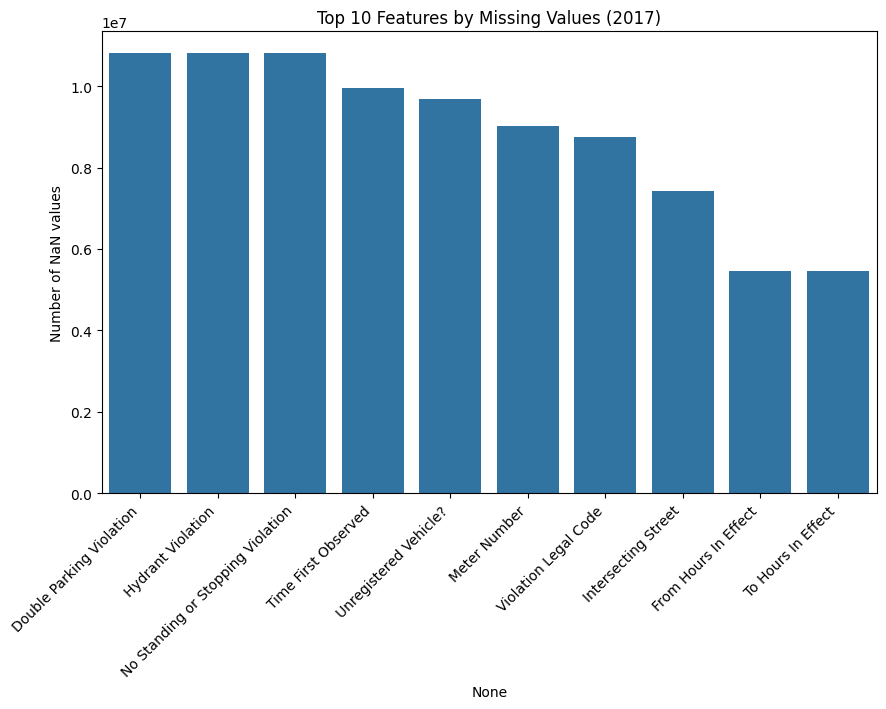

In [11]:
nan_df_2017 = df_2017.isna()

nan_counts = df_2017.isna().sum().sort_values(ascending=False)
top10 = nan_counts.head(10)

plt.figure(figsize=(10, 6))
sn.barplot(x=top10.index, y=top10.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of NaN values')
plt.title('Top 10 Features by Missing Values (2017)')
plt.show()

## Cities with most vioaltions in 2017

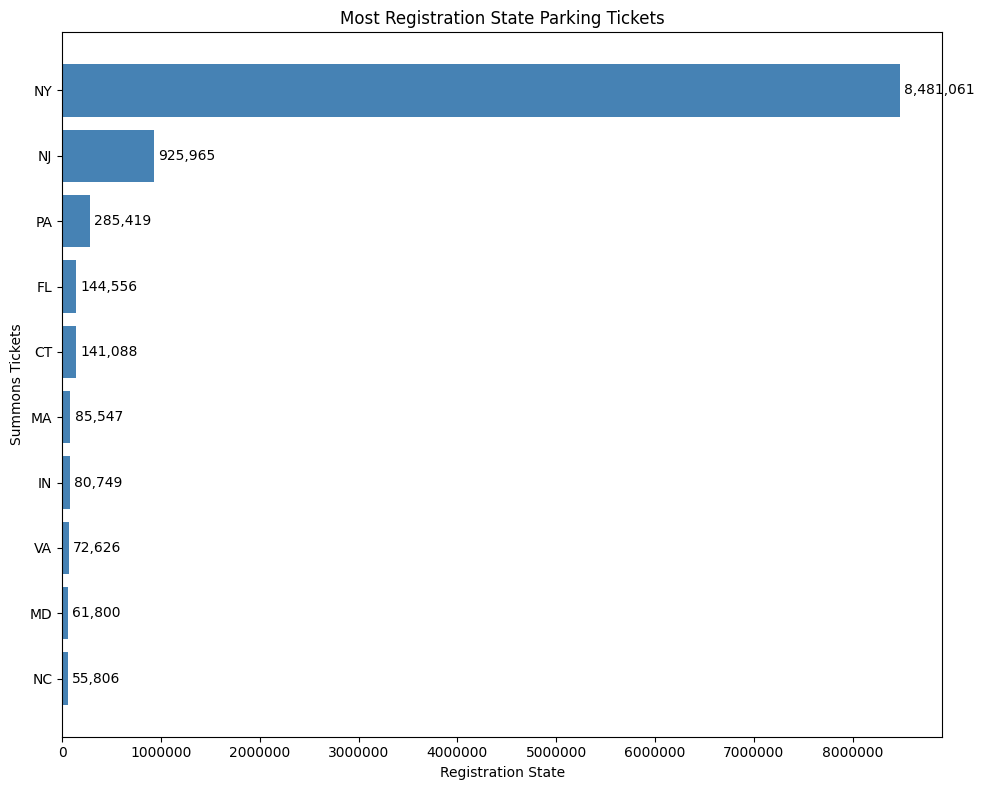

In [12]:
# Bar plot for registration state
top10_most_tickets_by_registrationState = (
    df_2017['Registration State']
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

x = top10_most_tickets_by_registrationState.index
y = top10_most_tickets_by_registrationState.values

plt.figure(figsize = (10,8))
bars = plt.barh(x,y,color='steelblue')
plt.title("Most Registration State Parking Tickets")
plt.ylabel("Summons Tickets")
plt.xlabel("Registration State")
plt.bar_label(bars, labels=[f"{v:,}" for v in top10_most_tickets_by_registrationState.values], padding=3)

plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()

plt.show()

NY placed the most summons number among other registration state. It has more than 8 millions parking tickets in 2017.

## Kind of Violations

Now, we wonder what are the violations happen in 2017

In [13]:
tickets_desc = str(df_2017['Violation Description'].unique())
print(tickets_desc)

['FAILURE TO STOP AT RED LIGHT' 'BUS LANE VIOLATION'
 '47-Double PKG-Midtown' '69-Failure to Disp Muni Recpt' nan
 'PHTO SCHOOL ZN SPEED VIOLATION' '19-No Stand (bus stop)'
 '71-Insp. Sticker Missing (NYS' '64-No STD Ex Con/DPL, D/S Dec'
 '38-Failure to Display Muni Rec' '71A-Insp Sticker Expired (NYS)'
 '14-No Standing' '75-No Match-Plate/Reg. Sticker' '10-No Stopping'
 '21-No Parking (street clean)' '50-Crosswalk' '48-Bike Lane'
 '68-Not Pkg. Comp. w Psted Sign' '51-Sidewalk' '09-Blocking the Box'
 '37-Expired Muni Meter' '16A-No Std (Com Veh) Non-COM'
 '20A-No Parking (Non-COM)' '46A-Double Parking (Non-COM)'
 '24-No Parking (exc auth veh)' '31-No Stand (Com. Mtr. Zone)'
 '40-Fire Hydrant' '13-No Stand (taxi stand)'
 '46B-Double Parking (Com-100Ft)' '16-No Std (Com Veh) Com Plate'
 '70A-Reg. Sticker Expired (NYS)' '42-Exp. Muni-Mtr (Com. Mtr. Z)'
 '74A-Improperly Displayed Plate' '78-Nighttime PKG on Res Street'
 '82-Unaltered Commerc Vehicle' '84-Platform lifts in low posit'
 '77-P

That's a lot of violations. Try to create word cloud with these violations. The result is we might find word "Bus" as the most word found in unique violations.

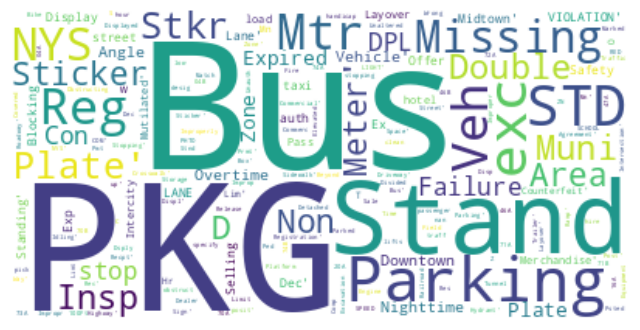

In [14]:
stopwords = set(STOPWORDS)
violation_wc = WordCloud(
    background_color='white',
    max_words=2000,
    stopwords=stopwords
)
violation_wc.generate(tickets_desc)
plt.figure(figsize = (8,6))
plt.imshow(violation_wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [15]:
brands = df_2017['Vehicle Make'].unique()
print(len(brands))

5703


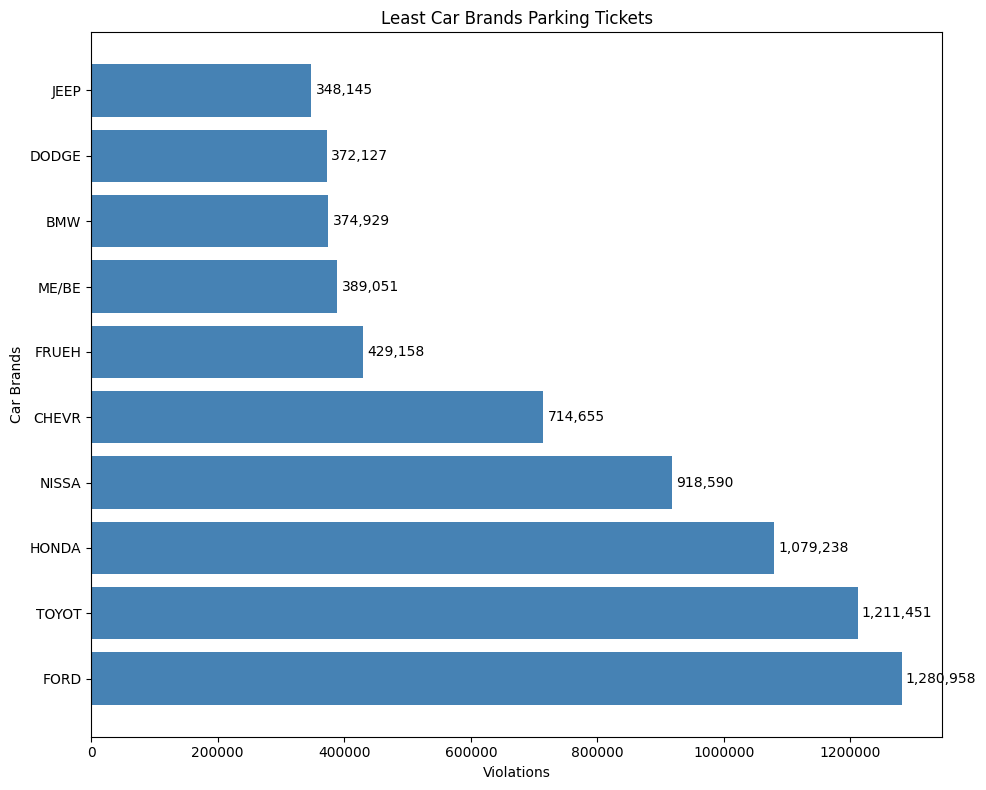

In [16]:
# Bar plot for Vehicle Make
top10_least_tickets_by_VehicleMake = (
    df_2017['Vehicle Make']
    .value_counts()
    .head(10)
    .sort_values(ascending=False)
)

x = top10_least_tickets_by_VehicleMake.index
y = top10_least_tickets_by_VehicleMake.values

plt.figure(figsize = (10,8))
bars = plt.barh(x,y,color='steelblue')
plt.title("Least Car Brands Parking Tickets")
plt.ylabel("Car Brands")
plt.xlabel("Violations")
plt.bar_label(bars, labels=[f"{v:,}" for v in top10_least_tickets_by_VehicleMake.values], padding=3)

plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()

plt.show()

Let's take a look which vehicle year that Violated while riding Jeep.

In [17]:
Jeep_df_2017 = df_2017[df_2017['Vehicle Make']=='JEEP']
Jeep_df_2017.head()

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,...,Vehicle Color,Unregistered Vehicle?,Vehicle Year,Meter Number,Feet From Curb,Violation Post Code,Violation Description,No Standing or Stopping Violation,Hydrant Violation,Double Parking Violation
34,7067047705,HFF1432,NY,PAS,09/23/2016,71,SUBN,JEEP,T,45590,...,BL,NaN,2014,NaN,0,32 4,71A-Insp Sticker Expired (NYS),NaN,NaN,NaN
38,4628491689,353XXL,FL,PAS,12/20/2016,36,UT,JEEP,V,0,...,BLK,NaN,2004,NaN,0,NaN,PHTO SCHOOL ZN SPEED VIOLATION,NaN,NaN,NaN
48,8263642668,HEA6308,NY,PAS,02/16/2017,71,SUBN,JEEP,T,13630,...,GY,NaN,2016,NaN,0,K,71A-Insp Sticker Expired (NYS),NaN,NaN,NaN
57,8446524806,GYG8911,NY,PAS,12/18/2016,24,SUBN,JEEP,T,29490,...,BK,NaN,2015,NaN,0,15 4,24-No Parking (exc auth veh),NaN,NaN,NaN
70,8564313893,HMJ8126,NY,PAS,06/26/2017,40,SUBN,JEEP,T,58590,...,RD,NaN,2009,NaN,6,T,40-Fire Hydrant,NaN,NaN,NaN


In [18]:
Jeep_df_2017_years = Jeep_df_2017['Vehicle Year'].unique()
print(Jeep_df_2017_years)

[2014 2004 2016 2015 2009 2013 2011 2006    0 2008 2002 2005 2017 1998
 2012 2010 1997 2003 2001 2007 1999 1978 1996 1995 1991 1993 2018 1994
 1989 1992 1988 1987 1990 2020 1979 2019 1980 2067 1986 1984 1977 1982
 1985 1983 2021 1972 2024 1970 1973 2061 2051 2042]


There are anomalies in vehicle years which is impossible for cars manufactured in 2061, 2051, and 2042. The possible happen is we found input error which alternate year number position. For example, it should be 2016 but it wrote as 2061 so is 2051 and 2042 which it should be 2015 and 2024. We need to change back those wrong data to be the correct format.